In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss
from torchvision import models
import torch.nn as nn

In [2]:
df=pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv')
print(df.head())
print(df.shape)
print(df.columns.tolist())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN 

In [3]:
all_labels=[]
for labels in df['Finding Labels']:
    all_labels.extend(labels.split('|'))
label_counts=pd.Series(all_labels).value_counts()
print(label_counts)
print(f'Total unique labels: {label_counts.shape}')

No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64
Total unique labels: (15,)


In [4]:
disease_labels = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

for disease in disease_labels:
    df[disease]=df['Finding Labels'].apply(lambda x:1 if disease in x.split('|') else 0)
print(df[disease_labels].head(10))
print(df[disease_labels].sum())

   Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  \
0            0             1              0      0         0          0   
1            0             1              0      0         0          1   
2            0             1              0      0         1          0   
3            0             0              0      0         0          0   
4            0             0              0      0         0          0   
5            0             0              0      0         0          0   
6            0             0              0      0         0          0   
7            0             0              0      0         0          0   
8            0             0              0      0         0          0   
9            0             0              0      0         0          0   

   Fibrosis  Hernia  Infiltration  Mass  Nodule  Pleural_Thickening  \
0         0       0             0     0       0                   0   
1         0       0             

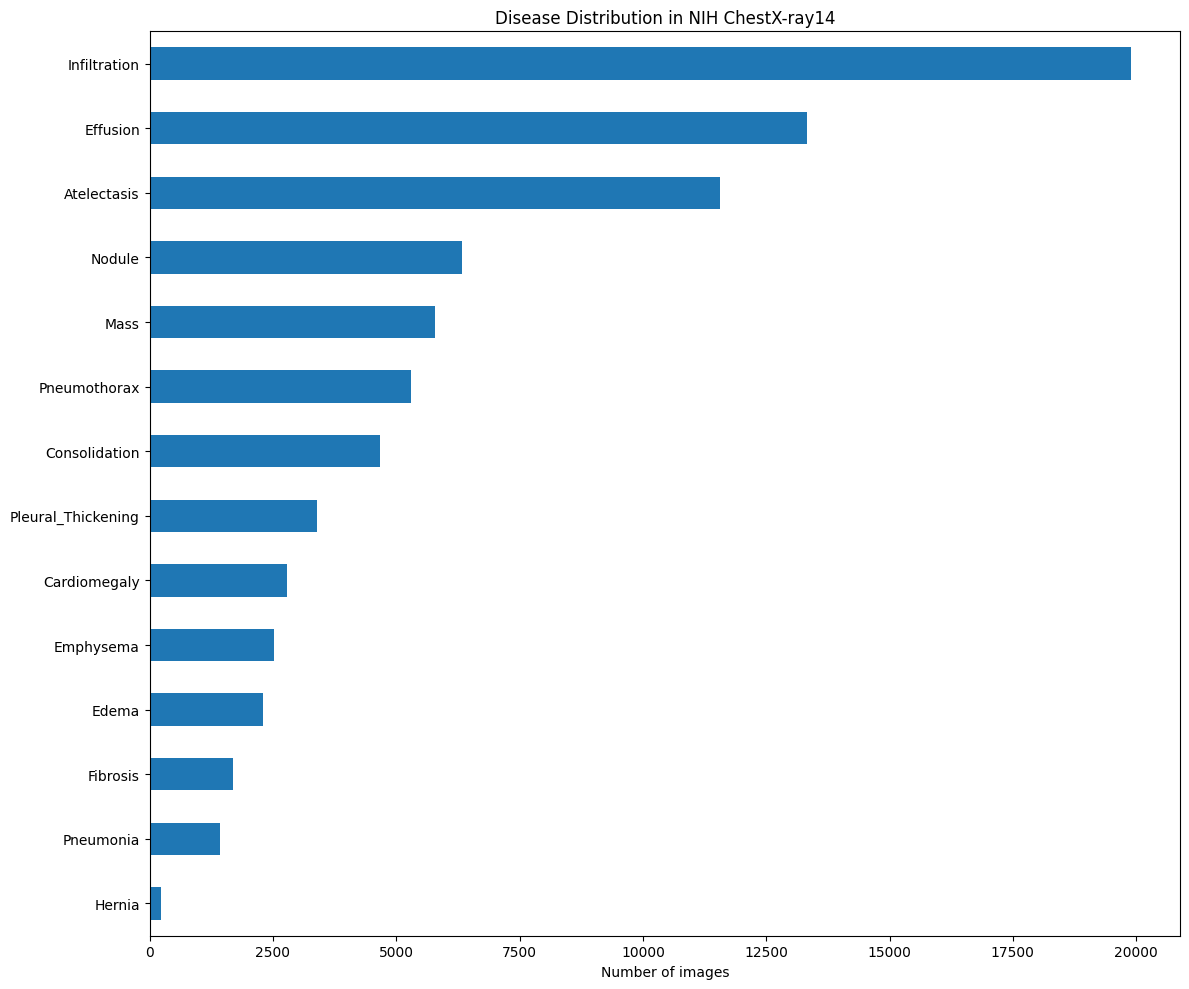

In [5]:
plt.figure(figsize=(12, 10))
df[disease_labels].sum().sort_values().plot(kind='barh')
plt.xlabel('Number of images')
plt.title('Disease Distribution in NIH ChestX-ray14')
plt.tight_layout()

In [6]:
# number of diseasse a patient has
df['num_diseases'] = df[disease_labels].sum(axis=1)
print(df['num_diseases'].value_counts().sort_index())

num_diseases
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64


In [7]:
for dirname, _, filenames in os.walk('/kaggle/input/datasets/organizations/nih-chest-xrays'):
    for filename in filenames:
        if 'split' in filename.lower() or 'train' in filename.lower() or 'test' in filename.lower():
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/nih-chest-xrays/data/test_list.txt
/kaggle/input/datasets/organizations/nih-chest-xrays/data/train_val_list.txt


In [8]:
#load official splits
with open('/kaggle/input/datasets/organizations/nih-chest-xrays/data/train_val_list.txt') as f:
    train_val_list = [line.strip() for line in f.readlines()]
with open('/kaggle/input/datasets/organizations/nih-chest-xrays/data/test_list.txt') as f:
    test_list = [line.strip() for line in f.readlines()]

print(f'Train/Val Images: {len(train_val_list)}')
print(f'Test Images: {len(test_list)}')

#df split
train_val_df = df[df['Image Index'].isin(train_val_list)]
test_df = df[df['Image Index'].isin(test_list)]

print(f'Train/Val df: {train_val_df.shape}')
print(f'Test df: {test_df.shape}')

Train/Val Images: 86524
Test Images: 25596
Train/Val df: (86524, 27)
Test df: (25596, 27)


In [9]:
# split train and val
unique_patients = train_val_df["Patient ID"].unique()

train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=0.10,
    random_state=42
)

train_df = train_val_df[
    train_val_df["Patient ID"].isin(train_patients)
].copy()

val_df = train_val_df[
    train_val_df["Patient ID"].isin(val_patients)
].copy()

In [10]:
train_patient_ids = set(train_df["Patient ID"])
val_patient_ids = set(val_df["Patient ID"])

overlap = train_patient_ids.intersection(val_patient_ids)

print("Training patients:", len(train_patient_ids))
print("Validation patients:", len(val_patient_ids))
print("Patient overlap:", len(overlap))

Training patients: 25207
Validation patients: 2801
Patient overlap: 0


In [11]:
assert len(overlap) == 0, "Patient leakage detected!"
print("No patient overlap between train and validation sets.")

No patient overlap between train and validation sets.


In [12]:
train_counts = train_df[disease_labels].sum()
val_counts = val_df[disease_labels].sum()

distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

print(distribution)

                    Train  Validation
Atelectasis          7405         875
Cardiomegaly         1549         158
Consolidation        2584         268
Edema                1253         125
Effusion             7852         807
Emphysema            1317         106
Fibrosis             1111         140
Hernia                122          19
Infiltration        12480        1302
Mass                 3646         388
Nodule               4247         461
Pleural_Thickening   1997         245
Pneumonia             782          94
Pneumothorax         2394         243


In [13]:
print(f'Train: {len(train_df)}')
print(f'Val: {len(val_df)}')
print(f'test: {len(test_df)}')

Train: 77988
Val: 8536
test: 25596


In [14]:
# image directories
for dirname, subdirs, filenames in os.walk('/kaggle/input/datasets/organizations/nih-chest-xrays'):
    if any(f.endswith('.png') for f in filenames):
        print(f'{dirname}: {len(filenames)} images')
        break

/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images: 10000 images


In [15]:
image_dirs = []
for dirname, subdirs, filenames in os.walk('/kaggle/input/datasets/organizations/nih-chest-xrays'):
    if any(f.endswith('.png') for f in filenames):
        image_dirs.append(dirname)

print(f'Total image folders: {len(image_dirs)}')
for d in image_dirs:
    print(d)

Total image folders: 12
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_008/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_004/images
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images


In [16]:
# image lookup
image_path_dict = {}
for image_dir in image_dirs:
    for filename in os.listdir(image_dir):
        if filename.endswith('.png'):
            image_path_dict[filename] = os.path.join(image_dir, filename)

print(f'Total images found: {len(image_path_dict)}')
print(f'Example: {list(image_path_dict.items())[0]}')

Total images found: 112120
Example: ('00006199_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png')


In [17]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_path_dict, disease_labels, transform):
        self.df=df.reset_index(drop=True)
        self.image_path_dict=image_path_dict
        self.disease_labels=disease_labels
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row=self.df.iloc[idx]

        img_path=self.image_path_dict[row['Image Index']]
        img=Image.open(img_path).convert('RGB')

        if self.transform:
            img=self.transform(img)

        labels=torch.tensor(row[self.disease_labels].values.astype(float),
                           dtype=torch.float32)

        return img, labels

In [18]:
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = ChestXrayDataset(train_df, image_path_dict, disease_labels, train_transform)
val_dataset = ChestXrayDataset(val_df, image_path_dict, disease_labels, val_transform)
test_dataset = ChestXrayDataset(test_df, image_path_dict, disease_labels, val_transform)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [19]:
images, labels = next(iter(train_loader))
print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Sample Labels: {labels[0]}')
print(f'Label sum per image: {labels.sum(axis=1)[:5]}')

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 14])
Sample Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Label sum per image: tensor([0., 1., 2., 1., 0.])


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [21]:
model=models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad=False

num_features=model.classifier.in_features
model.classifier=nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 14)
)
model=model.to(device)

total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total:,} | Trainable: {trainable:,}')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 158MB/s]


Total: 7,219,854 | Trainable: 265,998


In [22]:
# BCEWithLogitsLoss for multi-label classification
criterion = BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [28]:
import time

num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):

    start_time = time.time()

    model.train()

    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) > 0.5)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.numel()

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    model.eval()

    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = (torch.sigmoid(outputs) > 0.5)

            correct_val += (predictions == labels).sum().item()
            total_val += labels.numel() 

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(
            model.state_dict(),
            "best_densenet_nih.pth"
        )
        print(
            f"Best model saved"
            f"(Val Loss: {epoch_val_loss:.4f})"
        )

print("\nTraining Complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/20] | Train Loss: 0.1535 | Train Acc: 0.9554 | Val Loss: 0.1485 | Val Acc: 0.9562 | Time: 1255.7s
Best model saved(Val Loss: 0.1485)
Epoch [2/20] | Train Loss: 0.1531 | Train Acc: 0.9554 | Val Loss: 0.1482 | Val Acc: 0.9562 | Time: 1272.3s
Best model saved(Val Loss: 0.1482)
Epoch [3/20] | Train Loss: 0.1527 | Train Acc: 0.9554 | Val Loss: 0.1482 | Val Acc: 0.9562 | Time: 1253.3s
Best model saved(Val Loss: 0.1482)
Epoch [4/20] | Train Loss: 0.1524 | Train Acc: 0.9554 | Val Loss: 0.1473 | Val Acc: 0.9562 | Time: 1319.2s
Best model saved(Val Loss: 0.1473)
Epoch [5/20] | Train Loss: 0.1523 | Train Acc: 0.9554 | Val Loss: 0.1478 | Val Acc: 0.9563 | Time: 1313.1s
Epoch [6/20] | Train Loss: 0.1520 | Train Acc: 0.9554 | Val Loss: 0.1475 | Val Acc: 0.9563 | Time: 1306.5s
Epoch [7/20] | Train Loss: 0.1520 | Train Acc: 0.9554 | Val Loss: 0.1473 | Val Acc: 0.9563 | Time: 1286.9s
Epoch [8/20] | Train Loss: 0.1516 | Train Acc: 0.9554 | Val Loss: 0.1469 | Val Acc: 0.9563 | Time: 1326.5s
Best

In [29]:
model.load_state_dict(
    torch.load("best_densenet_nih.pth")
)
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

aurocs = {}

for i, disease in enumerate(disease_labels):
    try:
        auroc = roc_auc_score(
            all_labels[:, i],
            all_probs[:, i]
        )
        aurocs[disease] = auroc
    except:
        aurocs[disease] = np.nan

for disease, score in aurocs.items():
    print(f"{disease:20s}: {score:.4f}")

macro_auc = np.nanmean(list(aurocs.values()))
print(f"\nMacro AUROC: {macro_auc:.4f}")

Atelectasis         : 0.7340
Cardiomegaly        : 0.7049
Consolidation       : 0.7567
Edema               : 0.8882
Effusion            : 0.8354
Emphysema           : 0.7687
Fibrosis            : 0.7631
Hernia              : 0.7574
Infiltration        : 0.6685
Mass                : 0.6918
Nodule              : 0.6549
Pleural_Thickening  : 0.6923
Pneumonia           : 0.6588
Pneumothorax        : 0.7697

Macro AUROC: 0.7389


In [31]:
model.load_state_dict(torch.load('best_densenet_nih.pth'))
model = model.to(device)

# unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

# differential learning rates
optimizer = torch.optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
])

criterion = BCEWithLogitsLoss()

Trainable parameters: 7,219,854


In [32]:
import time

num_epochs = 5
best_val_loss = float('inf')

for epoch in range(num_epochs):

    start_time = time.time()

    model.train()

    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) > 0.5)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.numel()

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    model.eval()

    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = (torch.sigmoid(outputs) > 0.5)

            correct_val += (predictions == labels).sum().item()
            total_val += labels.numel() 

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(
            model.state_dict(),
            "best_densenet_nih.pth"
        )
        print(
            f"Best model saved"
            f"(Val Loss: {epoch_val_loss:.4f})"
        )

print("\nTraining Complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/5] | Train Loss: 0.1471 | Train Acc: 0.9556 | Val Loss: 0.1405 | Val Acc: 0.9571 | Time: 1241.5s
Best model saved(Val Loss: 0.1405)
Epoch [2/5] | Train Loss: 0.1429 | Train Acc: 0.9559 | Val Loss: 0.1374 | Val Acc: 0.9572 | Time: 1278.5s
Best model saved(Val Loss: 0.1374)
Epoch [3/5] | Train Loss: 0.1403 | Train Acc: 0.9560 | Val Loss: 0.1359 | Val Acc: 0.9573 | Time: 1245.2s
Best model saved(Val Loss: 0.1359)
Epoch [4/5] | Train Loss: 0.1378 | Train Acc: 0.9562 | Val Loss: 0.1345 | Val Acc: 0.9572 | Time: 1272.7s
Best model saved(Val Loss: 0.1345)
Epoch [5/5] | Train Loss: 0.1360 | Train Acc: 0.9564 | Val Loss: 0.1345 | Val Acc: 0.9573 | Time: 1230.1s
Best model saved(Val Loss: 0.1345)

Training Complete.
Best Validation Loss: 0.1345


In [35]:
model.load_state_dict(torch.load('best_densenet_nih.pth'))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

aurocs = {}
for i, disease in enumerate(disease_labels):
    try:
        auroc = roc_auc_score(all_labels[:, i], all_probs[:, i])
        aurocs[disease] = auroc
    except:
        aurocs[disease] = np.nan

for disease, score in aurocs.items():
    print(f'{disease:20s}: {score:.4f}')

macro_auc = np.nanmean(list(aurocs.values()))
print(f'\nMacro AUROC: {macro_auc:.4f}')

Atelectasis         : 0.7513
Cardiomegaly        : 0.8502
Consolidation       : 0.7140
Edema               : 0.8323
Effusion            : 0.8112
Emphysema           : 0.8716
Fibrosis            : 0.7838
Hernia              : 0.8577
Infiltration        : 0.6913
Mass                : 0.7638
Nodule              : 0.7215
Pleural_Thickening  : 0.7317
Pneumonia           : 0.6890
Pneumothorax        : 0.8408

Macro AUROC: 0.7793


In [26]:
model.load_state_dict(torch.load('/kaggle/input/models/adyanmukadam/best-densenet-nih/pytorch/default/1/best_densenet_nih.pth'))

for param in model.parameters():
    param.requires_grad=True

model=model.to(device)
optimizer=torch.optim.Adam(model.parameters(), lr=1e-5)

In [27]:
import time

num_epochs = 5
best_val_loss = 0.1345  # previous best

for epoch in range(num_epochs):

    start_time = time.time()

    model.train()

    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) > 0.5)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.numel()

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    model.eval()

    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = (torch.sigmoid(outputs) > 0.5)

            correct_val += (predictions == labels).sum().item()
            total_val += labels.numel() 

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(
            model.state_dict(),
            "best_densenet_nih.pth"
        )
        print(
            f"Best model saved"
            f"(Val Loss: {epoch_val_loss:.4f})"
        )

print("\nTraining Complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/5] | Train Loss: 0.1338 | Train Acc: 0.9565 | Val Loss: 0.1336 | Val Acc: 0.9574 | Time: 1556.1s
Best model saved(Val Loss: 0.1336)
Epoch [2/5] | Train Loss: 0.1319 | Train Acc: 0.9567 | Val Loss: 0.1328 | Val Acc: 0.9572 | Time: 1369.0s
Best model saved(Val Loss: 0.1328)
Epoch [3/5] | Train Loss: 0.1306 | Train Acc: 0.9569 | Val Loss: 0.1325 | Val Acc: 0.9573 | Time: 1307.3s
Best model saved(Val Loss: 0.1325)
Epoch [4/5] | Train Loss: 0.1292 | Train Acc: 0.9569 | Val Loss: 0.1330 | Val Acc: 0.9573 | Time: 1330.3s
Epoch [5/5] | Train Loss: 0.1279 | Train Acc: 0.9572 | Val Loss: 0.1332 | Val Acc: 0.9573 | Time: 1307.8s

Training Complete.
Best Validation Loss: 0.1325


In [31]:
model.load_state_dict(torch.load('best_densenet_nih.pth'))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

aurocs = {}
for i, disease in enumerate(disease_labels):
    try:
        auroc = roc_auc_score(all_labels[:, i], all_probs[:, i])
        aurocs[disease] = auroc
    except Exception as e:
        print(f'{disease}: {e}')
        aurocs[disease] = np.nan

for disease, score in aurocs.items():
    print(f'{disease:20s}: {score:.4f}')

macro_auc = np.nanmean(list(aurocs.values()))
print(f'\nMacro AUROC: {macro_auc:.4f}')

Atelectasis         : 0.7551
Cardiomegaly        : 0.8618
Consolidation       : 0.7223
Edema               : 0.8340
Effusion            : 0.8179
Emphysema           : 0.8887
Fibrosis            : 0.7798
Hernia              : 0.8774
Infiltration        : 0.6997
Mass                : 0.7775
Nodule              : 0.7297
Pleural_Thickening  : 0.7375
Pneumonia           : 0.6989
Pneumothorax        : 0.8455

Macro AUROC: 0.7876


In [32]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
results_df = pd.DataFrame({
    "Disease": list(aurocs.keys()),
    "AUROC": list(aurocs.values())
})

results_df.to_csv(
    "densenet_finetuned_results.csv",
    index=False
)